# Figure S13: Cross-metric age-effect correspondence across all 33 microstructural metrics

Figure S13 extends the Figure 5 cross-metric age-effect correspondence heatmap to all config metrics, with metric labels annotated as `METRIC (SOFTWARE)`.


In [19]:
suppressPackageStartupMessages({
  library(cowplot)
})
suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(purrr)
  library(stringr)
  library(ggplot2)
  library(fs)
  library(jsonlite)
  library(scales)
  library(grid)
  library(tibble)
})

find_config_path <- function() {
  env_path <- Sys.getenv("CONFIG_PATH", unset = "")
  if (nzchar(env_path) && file.exists(env_path)) {
    return(normalizePath(env_path, winslash = "/", mustWork = TRUE))
  }

  d <- normalizePath(getwd(), winslash = "/", mustWork = TRUE)
  repeat {
    cand <- file.path(d, "config.json")
    if (file.exists(cand)) {
      return(normalizePath(cand, winslash = "/", mustWork = TRUE))
    }
    parent <- dirname(d)
    if (identical(parent, d)) break
    d <- parent
  }

  stop("Could not locate config.json. Set CONFIG_PATH or launch Jupyter from within the project tree.")
}

config_path <- find_config_path()
config <- jsonlite::fromJSON(config_path)
project_root <- normalizePath(config$project_root, winslash = "/", mustWork = FALSE)

plot_style_file <- fs::path(project_root, "scripts", "utils", "plot_style.R")
if (!file.exists(plot_style_file)) stop("Missing plot style helper: ", plot_style_file)
source(plot_style_file)

plot_style <- get_plot_style(config)
font_family_use <- get_export_font_family()

# Try to register/use Arial explicitly for PDF/grid legend composition.
pdf_font_family <- font_family_use
if (requireNamespace("sysfonts", quietly = TRUE) && requireNamespace("showtext", quietly = TRUE)) {
  arial_path <- "/System/Library/Fonts/Supplemental/Arial.ttf"
  if (file.exists(arial_path)) {
    sysfonts::font_add("Arial", regular = arial_path)
    showtext::showtext_auto()
    pdf_font_family <- "Arial"
    message("[FONT] Registered Arial from: ", arial_path)
  } else {
    message("[FONT] Arial path not found, keeping font family: ", pdf_font_family)
  }
} else {
  message("[FONT] sysfonts/showtext not available; using font family: ", pdf_font_family)
}

figure_s13_dir <- fs::path(project_root, "figures", "Supplement", "FigureS13")
fs::dir_create(figure_s13_dir, recurse = TRUE)

age_effect_file <- fs::path(project_root, "data", "age_effects", "age_effects_all_outputs.rds")
if (!file.exists(age_effect_file)) stop("Missing assembled age-effect file: ", age_effect_file)

df_age_all <- readRDS(age_effect_file)
required_cols <- c("bundle", "metric", "qc_metric", "source", "output_type", "scanner_manufacturer", "age_effect_size")
missing_cols <- setdiff(required_cols, names(df_age_all))
if (length(missing_cols) > 0) {
  stop("Assembled age-effect data missing required columns: ", paste(missing_cols, collapse = ", "))
}



[FONT] sysfonts/showtext not available; using font family: Arial



[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Supplement/FigureS13/S13_cross_metric_age_effect_correlation_clustered.pdf

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Supplement/FigureS13/S13_cross_metric_age_effect_correlation_clustered.png



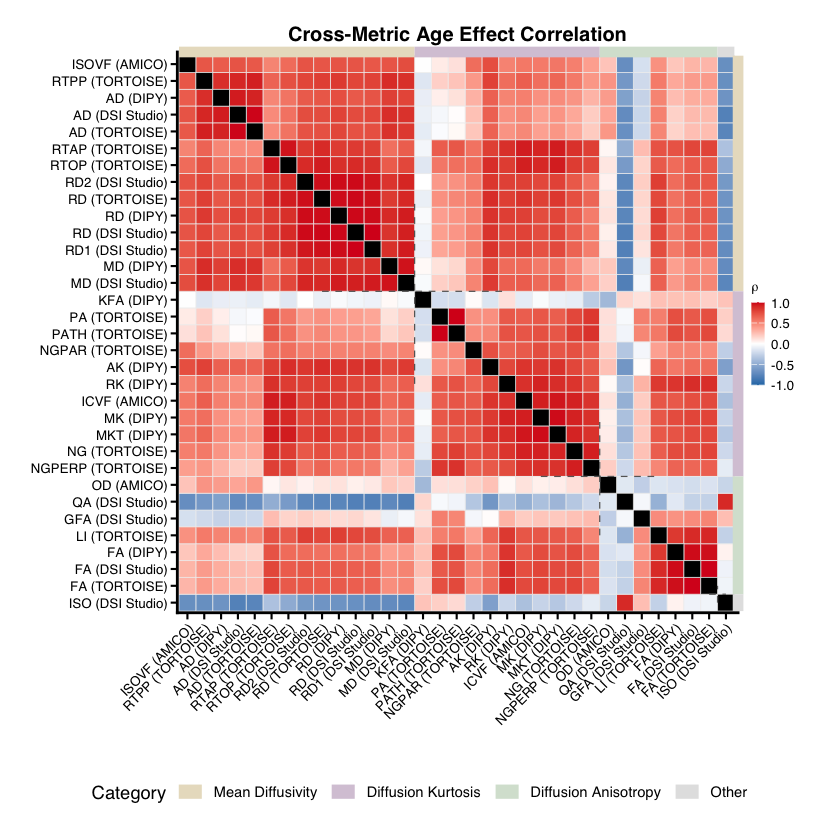

In [20]:
metrics_keep <- trimws(as.character(config$microstructural_metrics))
software_order <- c("DIPY", "AMICO", "TORTOISE", "DSI Studio")

s2_table_path <- fs::path(project_root, "scripts", "8_supplement", "supplementary_table_S2_microstructure.html")
if (!file.exists(s2_table_path)) {
  stop("Missing Supplementary Table S2 HTML: ", s2_table_path)
}

s2_lines <- readLines(s2_table_path, warn = FALSE)
current_section <- NA_character_
lookup_rows <- list()

for (ln in s2_lines) {
  if (str_detect(ln, '<tr class="section"><td colspan="5">')) {
    current_section <- str_match(ln, '<tr class="section"><td colspan="5">([^<]+)</td></tr>')[, 2]
  }

  if (str_detect(ln, '<tr class="(mean|kurtosis|aniso|neutral)">')) {
    m <- str_match(
      ln,
      '<tr class="[^\"]*"><td>([^<]+)</td><td><code>([^<]+)</code></td><td>[^<]*</td><td>[^<]*</td><td>([^<]*)</td></tr>'
    )

    if (!all(is.na(m))) {
      model <- m[, 2]
      param <- m[, 3]
      category <- m[, 4]
      if (is.na(category) || category == "") category <- "Other"

      prefix <- case_when(
        model == "DKI" ~ "DKI",
        model == "GQI" ~ "GQI",
        model == "MAPMRI" ~ "MAPMRI",
        model == "NODDI" ~ "NODDI",
        model == "Tensor" & current_section == "qsirecon-DSIStudio" ~ "GQI",
        model == "Tensor" & current_section == "qsirecon-TORTOISE_model-MAPMRI" ~ "MAPMRI",
        TRUE ~ NA_character_
      )

      if (!is.na(prefix)) {
        lookup_rows[[length(lookup_rows) + 1]] <- tibble(
          metric = paste0(prefix, "_", param),
          category = category
        )
      }
    }
  }
}

category_lookup <- bind_rows(lookup_rows) %>%
  distinct(metric, .keep_all = TRUE)

category_order <- c(
  "Mean Diffusivity",
  "Diffusion Kurtosis",
  "Diffusion Anisotropy",
  "Other"
)

metric_meta <- tibble(metric = metrics_keep) %>%
  mutate(
    software = case_when(
      str_starts(metric, "DKI_") ~ "DIPY",
      str_starts(metric, "NODDI_") ~ "AMICO",
      str_starts(metric, "MAPMRI_") ~ "TORTOISE",
      str_starts(metric, "GQI_") ~ "DSI Studio",
      TRUE ~ "Other"
    ),
    metric_short = if_else(
      str_detect(metric, "_"),
      str_to_upper(str_remove(metric, "^[^_]+_")),
      str_to_upper(metric)
    ),
    metric_label = paste0(metric_short, " (", software, ")")
  ) %>%
  left_join(category_lookup, by = "metric") %>%
  mutate(category = coalesce(category, "Other")) %>%
  filter(software %in% software_order)

if (nrow(metric_meta) < 2) {
  stop("Need at least two configured metrics from the supported software groups.")
}

label_map <- setNames(metric_meta$metric_label, metric_meta$metric)

df_age <- df_age_all %>%
  filter(
    output_type == "pooled",
    qc_metric == "no_quality",
    scanner_manufacturer == "all",
    source == "harmonized",
    metric %in% metric_meta$metric,
    !is.na(bundle),
    !is.na(age_effect_size)
  ) %>%
  transmute(
    bundle = as.character(bundle),
    metric = as.character(metric),
    age_effect_size = as.numeric(age_effect_size)
  )

if (nrow(df_age) == 0) {
  stop("No rows for FigureS13 pooled harmonized age effects.")
}

wide_effects <- df_age %>%
  distinct(bundle, metric, age_effect_size) %>%
  pivot_wider(names_from = metric, values_from = age_effect_size)

metric_cols <- intersect(metric_meta$metric, names(wide_effects))
if (length(metric_cols) < 2) {
  stop("Need at least two metrics with data to compute the correlation heatmap.")
}

mat <- wide_effects %>%
  select(all_of(metric_cols)) %>%
  as.matrix()

cor_mat <- cor(mat, method = "spearman", use = "pairwise.complete.obs")

metric_meta_present <- metric_meta %>%
  filter(metric %in% colnames(cor_mat)) %>%
  mutate(category = factor(category, levels = category_order))

# Order metrics by S2 category; cluster only within each category block.
metric_order <- metric_meta_present %>%
  arrange(category, software, metric_short, metric) %>%
  group_split(category, .keep = TRUE) %>%
  purrr::map(function(df_block) {
    block_metrics <- intersect(df_block$metric, colnames(cor_mat))
    if (length(block_metrics) == 0) return(character(0))
    if (length(block_metrics) == 1) return(block_metrics)

    block_cor <- cor_mat[block_metrics, block_metrics, drop = FALSE]
    block_dist <- as.dist(1 - abs(block_cor))
    block_hc <- hclust(block_dist, method = "average")
    colnames(block_cor)[block_hc$order]
  }) %>%
  unlist(use.names = FALSE)

metric_order <- unique(c(metric_order, setdiff(colnames(cor_mat), metric_order)))

metric_order_df <- tibble(metric = metric_order, x = seq_along(metric_order)) %>%
  left_join(metric_meta_present %>% select(metric, category), by = "metric")

category_colors <- c(
  "Mean Diffusivity" = "#e9dfc8",
  "Diffusion Kurtosis" = "#d8c9d9",
  "Diffusion Anisotropy" = "#d7e3d5",
  "Other" = "#e3e3e3"
)

n_metrics <- length(metric_order)

category_bounds <- metric_order_df %>%
  group_by(category) %>%
  summarise(
    xmin = min(x) - 0.5,
    xmax = max(x) + 0.5,
    n_cat = dplyr::n(),
    .groups = "drop"
  ) %>%
  arrange(xmin) %>%
  mutate(cat_color = unname(category_colors[as.character(category)]))

n_bounds <- nrow(category_bounds)
separator_df <- category_bounds %>%
  mutate(n_next = dplyr::lead(n_cat)) %>%
  slice_head(n = max(0, n_bounds - 1)) %>%
  mutate(
    xint = xmax,
    diag_y = n_metrics - xint + 1,
    seg_span = pmax(1, pmin(n_cat, n_next)),
    y_start = pmax(0.5, diag_y - seg_span / 2),
    y_end = pmin(n_metrics + 0.5, diag_y + seg_span / 2),
    x_start = pmax(0.5, xint - seg_span / 2),
    x_end = pmin(n_metrics + 0.5, xint + seg_span / 2)
  )

# Category strips: top (x-axis span) and right (y-axis span mirrored to matrix orientation)
strip_top <- category_bounds %>%
  transmute(category, cat_color, x = xmin, xend = xmax, y = n_metrics + 0.72, yend = n_metrics + 0.72)

strip_right <- category_bounds %>%
  transmute(
    category,
    cat_color,
    x = n_metrics + 0.72,
    xend = n_metrics + 0.72,
    y = n_metrics - xmax + 1,
    yend = n_metrics - xmin + 1
  )

heat_df <- as.data.frame(as.table(cor_mat), stringsAsFactors = FALSE) %>%
  rename(metric_y = Var1, metric_x = Var2, rho = Freq) %>%
  mutate(
    is_diag = metric_x == metric_y,
    metric_x = factor(metric_x, levels = metric_order),
    metric_y = factor(metric_y, levels = rev(metric_order))
  )

p_s13 <- ggplot() +
  geom_tile(
    data = filter(heat_df, !is_diag),
    aes(x = metric_x, y = metric_y, fill = rho),
    color = "#F0F0F0",
    linewidth = 0.2
  ) +
  geom_tile(
    data = filter(heat_df, is_diag),
    aes(x = metric_x, y = metric_y),
    fill = "black",
    color = "#F0F0F0",
    linewidth = 0.2
  ) +
  scale_fill_gradient2(
    low = "#2C7BB6",
    mid = "#FFFFFF",
    high = "#D7191C",
    midpoint = 0,
    limits = c(-1, 1),
    breaks = c(-1, -0.5, 0, 0.5, 1),
    oob = squish,
    name = expression(rho)
  ) +
  geom_segment(data = separator_df, aes(x = xint, xend = xint, y = y_start, yend = y_end), inherit.aes = FALSE, linewidth = 0.35, color = "#666666", linetype = "dashed") +
  geom_segment(data = separator_df, aes(x = x_start, xend = x_end, y = diag_y, yend = diag_y), inherit.aes = FALSE, linewidth = 0.35, color = "#666666", linetype = "dashed") +
  geom_segment(data = strip_top, aes(x = x, xend = xend, y = y, yend = yend, color = category), inherit.aes = FALSE, linewidth = 3.0, lineend = "butt") +
  geom_segment(data = strip_right, aes(x = x, xend = xend, y = y, yend = yend, color = category), inherit.aes = FALSE, linewidth = 3.0, lineend = "butt") +
  scale_color_manual(values = category_colors, breaks = category_order, name = "Category") +
  scale_x_discrete(labels = label_map[metric_order]) +
  scale_y_discrete(labels = rev(label_map[metric_order])) +
  guides(
    color = guide_legend(order = 1, nrow = 1, byrow = TRUE, override.aes = list(linewidth = 4)),
    fill = guide_colorbar(order = 2)
  ) +
  coord_fixed(clip = "off") +
  labs(
    x = NULL,
    y = NULL,
    title = "Cross-Metric Age Effect Correlation"
  ) +
  make_theme_pub(
    style = plot_style,
    legend_position = "right",
    axis_title_pt = 8,
    axis_text_pt = 8,
    legend_title_pt = 8,
    legend_text_pt = 8,
    base_size_pt = 8
  ) +
  theme(
    text = element_text(family = font_family_use),
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1, size = 8),
    axis.text.y = element_text(size = 8),
    panel.grid = element_blank(),
    plot.title = element_text(size = 12, hjust = 0.5),
    legend.key.height = unit(10, "pt"),
    legend.key.width = unit(8, "pt"),
    legend.box = "vertical",
    legend.margin = margin(t = 2, r = 0, b = 0, l = 0),
    plot.margin = margin(t = 16, r = 16, b = 10, l = 10)
  )

# Split legends: keep correlation colorbar on the right, put category legend at bottom.
# Use a device-safe font for cowplot legend extraction/composition.
safe_font_family <- "sans"
p_s13_main <- p_s13 +
  guides(
    color = "none",
    fill = guide_colorbar(order = 1)
  ) +
  theme(legend.position = "right", text = element_text(family = safe_font_family))

category_leg_df <- tibble(
  category = factor(category_order, levels = category_order),
  x = 0,
  xend = 1,
  y = 0,
  yend = 0
)

p_s13_cat_legend <- ggplot(category_leg_df, aes(x = x, xend = xend, y = y, yend = yend, color = category)) +
  geom_segment(linewidth = 4, lineend = "butt") +
  scale_color_manual(values = category_colors, breaks = category_order, name = "Category") +
  guides(color = guide_legend(nrow = 1, byrow = TRUE, override.aes = list(linewidth = 4))) +
  theme_void(base_family = safe_font_family) +
  theme(legend.position = "bottom")

legend_bottom <- cowplot::get_legend(p_s13_cat_legend)
p_s13_combined <- cowplot::plot_grid(p_s13_main, legend_bottom, ncol = 1, rel_heights = c(1, 0.13))

p_s13_combined

save_plot_outputs(
  plot_obj = p_s13_combined,
  stub = "S13_cross_metric_age_effect_correlation_clustered",
  out_dir = figure_s13_dir,
  width_in = 8,
  height_in = 8
)
